In [4]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('master_coordinates.csv')

def prepare_dataset(df):
    # Calculate Euclidean Distance (The 'Tap' Signal)
    df['distance'] = np.sqrt(
        (df['thumb_x'] - df['index_x'])**2 +
        (df['thumb_y'] - df['index_y'])**2 +
        (df['thumb_z'] - df['index_z'])**2
    )

    # Labeling logic: CONTROL = 0, ID (Patient) = 1
    df['label'] = df['video_id'].apply(lambda x: 0 if 'CONTROL' in x.upper() else 1)

    processed_sequences = []
    labels = []

    # Process each video as a single "sample" for the AI
    for video_id, group in df.groupby('video_id'):
        dist_signal = group['distance'].values

        # Clinical Smoothing: Removes camera jitter but keeps the tap peaks
        if len(dist_signal) > 15:
            smoothed = savgol_filter(dist_signal, window_length=11, polyorder=3)

            # Normalize: Scale distance to 0-1 (handles different hand sizes)
            normalized = (smoothed - np.min(smoothed)) / (np.max(smoothed) - np.min(smoothed) + 1e-6)

            # Padding/Truncating: Ensure every sample is exactly 600 frames (approx 10-20s)
            if len(normalized) > 600:
                normalized = normalized[:600]
            else:
                normalized = np.pad(normalized, (0, 600 - len(normalized)), 'constant')

            processed_sequences.append(normalized)
            labels.append(group['label'].iloc[0])

    return np.array(processed_sequences), np.array(labels)

# Execute Preprocessing
X, y = prepare_dataset(df)

# Reshape for the AI Model [Samples, TimeSteps, Features]
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"Data Prepared!")
print(f"Total Samples (Videos): {X.shape[0]}")
print(f"Frames per Video: {X.shape[1]}")
print(f"Label Distribution (0=Healthy, 1=PD): {np.bincount(y)}")

Data Prepared!
Total Samples (Videos): 226
Frames per Video: 600
Label Distribution (0=Healthy, 1=PD): [ 77 149]


--- Phase 2: Preprocessing & Clinical Feature Engineering Complete ---
Total Videos Processed: 226
Data Shape: (226, 600, 1) (Videos, Frames, Signal)
Healthy (0) vs Parkinson's (1) Count: [ 77 149]


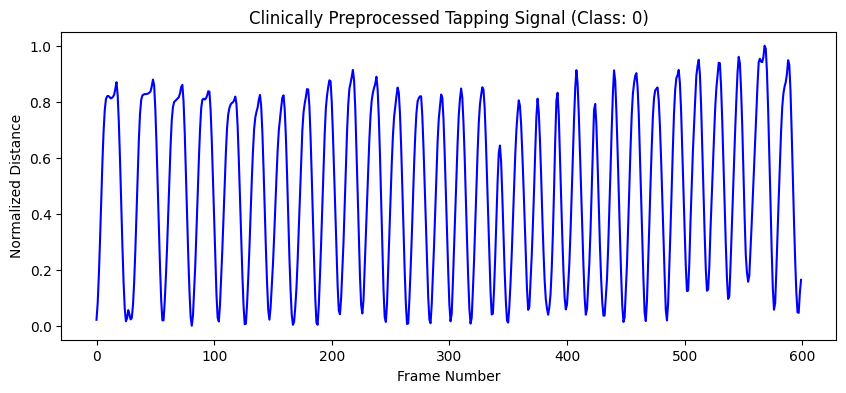

In [5]:
import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt

# 1. Load the data from your uploaded CSV
df = pd.read_csv('master_coordinates.csv')

def preprocess_clinical_features(df):
    # Calculate Euclidean Distance between Thumb (4) and Index (8)
    # This represents the "Gap" of the finger tap
    df['distance'] = np.sqrt(
        (df['thumb_x'] - df['index_x'])**2 +
        (df['thumb_y'] - df['index_y'])**2 +
        (df['thumb_z'] - df['index_z'])**2
    )

    # Assign Labels: Healthy (0) for CONTROL files, PD (1) for ID files
    df['label'] = df['video_id'].apply(lambda x: 0 if 'CONTROL' in x.upper() else 1)

    processed_sequences = []
    labels = []

    # Process each video to create one "Tapping Time-Series"
    for video_id, group in df.groupby('video_id'):
        dist_signal = group['distance'].values

        # Clinical Requirement: We need enough data points for the filter
        if len(dist_signal) > 30:
            # SAVITZKY-GOLAY FILTER:
            # Removes camera 'jitter' while preserving the true speed of the tap
            smoothed = savgol_filter(dist_signal, window_length=11, polyorder=3)

            # NORMALIZATION (Min-Max Scaling):
            # Ensures the tap range is 0 to 1 regardless of hand size or distance from camera
            normalized = (smoothed - np.min(smoothed)) / (np.max(smoothed) - np.min(smoothed) + 1e-6)

            # STANDARDIZATION OF LENGTH:
            # Deep Learning models need equal input sizes. We fix this to 600 frames.
            if len(normalized) > 600:
                normalized = normalized[:600] # Truncate if too long
            else:
                normalized = np.pad(normalized, (0, 600 - len(normalized)), 'constant') # Pad if too short

            processed_sequences.append(normalized)
            labels.append(group['label'].iloc[0])

    return np.array(processed_sequences), np.array(labels)

# Execute Phase 2
X, y = preprocess_clinical_features(df)

# Reshape for the AI Model [Samples, TimeSteps, Features]
# Our feature is 1 (The Distance Signal)
X = X.reshape(X.shape[0], X.shape[1], 1)

print("--- Phase 2: Preprocessing & Clinical Feature Engineering Complete ---")
print(f"Total Videos Processed: {X.shape[0]}")
print(f"Data Shape: {X.shape} (Videos, Frames, Signal)")
print(f"Healthy (0) vs Parkinson's (1) Count: {np.bincount(y)}")

# VISUAL CHECK: Plotting one signal to verify quality
plt.figure(figsize=(10, 4))
plt.plot(X[0], color='blue')
plt.title(f"Clinically Preprocessed Tapping Signal (Class: {y[0]})")
plt.xlabel("Frame Number")
plt.ylabel("Normalized Distance")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Split into Training (80%) and Testing (20%)
# We use X and y from your successful Phase 2 run
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

def aggressive_balanced_augmentation(X_data, y_data, target_per_class=1200):
    X_aug, y_aug = [], []

    for label_type in [0, 1]:
        # Filter samples by class (0 for Healthy, 1 for PD)
        class_indices = np.where(y_data == label_type)[0]
        class_samples = X_data[class_indices]

        num_originals = len(class_samples)
        # Calculate how many variations needed per sample to reach ~1200
        augs_per_sample = (target_per_class // num_originals)

        for signal in class_samples:
            # Add Original
            X_aug.append(signal)
            y_aug.append(label_type)

            # Create unique variations
            for _ in range(augs_per_sample):
                # A. Jitter (Noise)
                noise = np.random.normal(0, 0.005, signal.shape)
                # B. Scaling (Size)
                scale = np.random.uniform(0.95, 1.05)
                # C. Time Shifting
                shift = np.roll(signal, shift=np.random.randint(-5, 5))

                augmented_signal = (shift * scale) + noise
                X_aug.append(augmented_signal)
                y_aug.append(label_type)

    return np.array(X_aug), np.array(y_aug)

# 2. Apply to reach a balanced ~2,400 training samples
X_train_final, y_train_final = aggressive_balanced_augmentation(X_train, y_train, target_per_class=1200)

print(f"--- Phase 3: Optimized Augmentation Complete ---")
print(f"Original Training Samples: {len(X_train)}")
print(f"Final Balanced Training Samples: {len(X_train_final)}")
print(f"Untouched Testing Samples: {len(X_test)}")
print(f"Balance -> Healthy (0): {np.sum(y_train_final == 0)} | PD (1): {np.sum(y_train_final == 1)}")

--- Phase 3: Optimized Augmentation Complete ---
Original Training Samples: 180
Final Balanced Training Samples: 2529
Untouched Testing Samples: 46
Balance -> Healthy (0): 1220 | PD (1): 1309


In [9]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

def build_noble_attention_model(input_shape):
    inputs = layers.Input(shape=input_shape)

    # 1. Spatial Feature Extraction (CNN)
    x = layers.Conv1D(filters=64, kernel_size=5, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.2)(x)

    # 2. Temporal Sequence Analysis (BiLSTM)
    # return_sequences=True is required for the Attention layer
    lstm_out = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    # 3. Attention Mechanism
    # This layer assigns a 'weight' to every frame based on its clinical importance
    attention = layers.Dense(1, activation='tanh')(lstm_out)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(128)(attention) # 128 = 64 units * 2 directions
    attention = layers.Permute([2, 1])(attention)

    # Multiply the BiLSTM output by the attention weights
    sent_representation = layers.Multiply()([lstm_out, attention])
    # Sum the weighted features into a single vector
    sent_representation = layers.Lambda(lambda xin: tf.reduce_sum(xin, axis=1))(sent_representation)

    # 4. Final Classification
    x = layers.Dense(64, activation='relu')(sent_representation)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=outputs)

    # Optimizer & Metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.Recall(name='recall')]
    )

    return model

# Initialize the Model
# Input shape is (600 frames, 1 feature)
model = build_noble_attention_model((600, 1))

# Set up Callbacks to save the best model and prevent overfitting
callbacks = [
    ModelCheckpoint('best_parkinsons_model.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

# 5. Start Training
print("Starting Training on Balanced Dataset...")
history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Starting Training on Balanced Dataset...
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.6093 - auc: 0.6678 - loss: 0.6443 - recall: 0.5726
Epoch 1: val_auc improved from None to 0.79271, saving model to best_parkinsons_model.h5



Epoch 1: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 390ms/step - accuracy: 0.6702 - auc: 0.7334 - loss: 0.6101 - recall: 0.6211 - val_accuracy: 0.6522 - val_auc: 0.7927 - val_loss: 0.6089 - val_recall: 1.0000
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.7291 - auc: 0.7999 - loss: 0.5447 - recall: 0.7104
Epoch 2: val_auc did not improve from 0.79271
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 378ms/step - accuracy: 0.7220 - auc: 0.7859 - loss: 0.5575 - recall: 0.7273 - val_accuracy: 0.6522 - val_auc: 0.7875 - val_loss: 0.6083 - val_recall: 1.0000
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.7157 - auc: 0.7856 - loss: 0.5566 - recall: 0.6744
Epoch 3: val_auc did not improve from 0.79271
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 386ms/step - accuracy: 0.7110 - auc: 0.7867 - loss: 0.5544 - recall: 0.6990 - val_accuracy: 0.6522 - val_auc: 0.7844 - val_loss: 0.5811 - val_recall: 0.9667
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/ste


Epoch 8: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - accuracy: 0.7671 - auc: 0.8427 - loss: 0.4787 - recall: 0.7525 - val_accuracy: 0.7391 - val_auc: 0.8073 - val_loss: 0.5413 - val_recall: 0.6667
Epoch 9/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7774 - auc: 0.8562 - loss: 0.4637 - recall: 0.7458
Epoch 9: val_auc did not improve from 0.80729
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.7718 - auc: 0.8456 - loss: 0.4736 - recall: 0.7273 - val_accuracy: 0.5870 - val_auc: 0.7604 - val_loss: 0.7132 - val_recall: 0.4000
Epoch 10/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7607 - auc: 0.8371 - loss: 0.4907 - recall: 0.6599
Epoch 10: val_auc improved from 0.80729 to 0.83646, saving model to best_parkinsons_model.h5



Epoch 10: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.7687 - auc: 0.8438 - loss: 0.4768 - recall: 0.7013 - val_accuracy: 0.7174 - val_auc: 0.8365 - val_loss: 0.5615 - val_recall: 0.6333
Epoch 11/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.8096 - auc: 0.8673 - loss: 0.4394 - recall: 0.7611
Epoch 11: val_auc improved from 0.83646 to 0.84479, saving model to best_parkinsons_model.h5



Epoch 11: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 377ms/step - accuracy: 0.8062 - auc: 0.8691 - loss: 0.4318 - recall: 0.7670 - val_accuracy: 0.7391 - val_auc: 0.8448 - val_loss: 0.5292 - val_recall: 0.6667
Epoch 12/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.8056 - auc: 0.8670 - loss: 0.4329 - recall: 0.7507
Epoch 12: val_auc did not improve from 0.84479
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 375ms/step - accuracy: 0.8102 - auc: 0.8764 - loss: 0.4214 - recall: 0.7693 - val_accuracy: 0.7391 - val_auc: 0.8333 - val_loss: 0.5179 - val_recall: 0.7000
Epoch 13/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.8172 - auc: 0.8787 - loss: 0.4120 - recall: 0.7373
Epoch 13: val_auc did not improve from 0.84479
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 376ms/step - accuracy: 0.8173 - auc: 0.8814 - loss: 0.4134 - recall: 0.7617 - val_accuracy: 0.7391 - val_auc: 0.8167 - val_loss: 0.5434 - val_recall: 0.7000
Epoch 14/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 376


Epoch 15: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 381ms/step - accuracy: 0.8312 - auc: 0.8948 - loss: 0.3823 - recall: 0.7800 - val_accuracy: 0.6739 - val_auc: 0.8479 - val_loss: 0.6059 - val_recall: 0.6333
Epoch 16/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8266 - auc: 0.8871 - loss: 0.3947 - recall: 0.7756
Epoch 16: val_auc improved from 0.84792 to 0.85208, saving model to best_parkinsons_model.h5



Epoch 16: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - accuracy: 0.8399 - auc: 0.9000 - loss: 0.3702 - recall: 0.7922 - val_accuracy: 0.7174 - val_auc: 0.8521 - val_loss: 0.5690 - val_recall: 0.6333
Epoch 17/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8144 - auc: 0.9001 - loss: 0.3914 - recall: 0.7178
Epoch 17: val_auc improved from 0.85208 to 0.86979, saving model to best_parkinsons_model.h5



Epoch 17: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.8383 - auc: 0.9097 - loss: 0.3628 - recall: 0.7785 - val_accuracy: 0.6957 - val_auc: 0.8698 - val_loss: 0.5615 - val_recall: 0.6667
Epoch 18/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8472 - auc: 0.9070 - loss: 0.3610 - recall: 0.8017
Epoch 18: val_auc did not improve from 0.86979
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.8474 - auc: 0.9105 - loss: 0.3549 - recall: 0.7953 - val_accuracy: 0.7391 - val_auc: 0.8438 - val_loss: 0.5822 - val_recall: 0.7667
Epoch 19/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.8701 - auc: 0.9326 - loss: 0.3112 - recall: 0.8452
Epoch 19: val_auc did not improve from 0.86979
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 366ms/step - accuracy: 0.8628 - auc: 0.9281 - loss: 0.3191 - recall: 0.8235 - val_accuracy: 0.7174 - val_auc: 0.8510 - val_loss: 0.5396 - val_recall: 0.7000
Epoch 20/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377


Epoch 23: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - accuracy: 0.8830 - auc: 0.9483 - loss: 0.2733 - recall: 0.8411 - val_accuracy: 0.7174 - val_auc: 0.8719 - val_loss: 0.6768 - val_recall: 0.6333
Epoch 24/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8914 - auc: 0.9548 - loss: 0.2616 - recall: 0.8417
Epoch 24: val_auc did not improve from 0.87187
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - accuracy: 0.8992 - auc: 0.9572 - loss: 0.2521 - recall: 0.8594 - val_accuracy: 0.6739 - val_auc: 0.7740 - val_loss: 0.7511 - val_recall: 0.6667
Epoch 25/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step - accuracy: 0.8555 - auc: 0.9362 - loss: 0.3079 - recall: 0.7716
Epoch 25: val_auc did not improve from 0.87187
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 373ms/step - accuracy: 0.8747 - auc: 0.9420 - loss: 0.2915 - recall: 0.8136 - val_accuracy: 0.7609 - val_auc: 0.7865 - val_loss: 0.7059 - val_recall: 0.7667
Epoch 26/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 370


Epoch 27: finished saving model to best_parkinsons_model.h5
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 379ms/step - accuracy: 0.8541 - auc: 0.9241 - loss: 0.3483 - recall: 0.8075 - val_accuracy: 0.7391 - val_auc: 0.9000 - val_loss: 0.4615 - val_recall: 0.6667
Epoch 28/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8902 - auc: 0.9516 - loss: 0.2785 - recall: 0.8700
Epoch 28: val_auc did not improve from 0.90000
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 378ms/step - accuracy: 0.8940 - auc: 0.9522 - loss: 0.2680 - recall: 0.8648 - val_accuracy: 0.7609 - val_auc: 0.8677 - val_loss: 0.4883 - val_recall: 0.8000
Epoch 29/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.8395 - auc: 0.9280 - loss: 0.3383 - recall: 0.8373
Epoch 29: val_auc did not improve from 0.90000
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 379ms/step - accuracy: 0.8640 - auc: 0.9384 - loss: 0.3042 - recall: 0.8388 - val_accuracy: 0.6522 - val_auc: 0.8073 - val_loss: 0.6747 - val_recall: 0.6000
Epoch 30/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 376

Generating predictions using the trained model...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 858ms/step


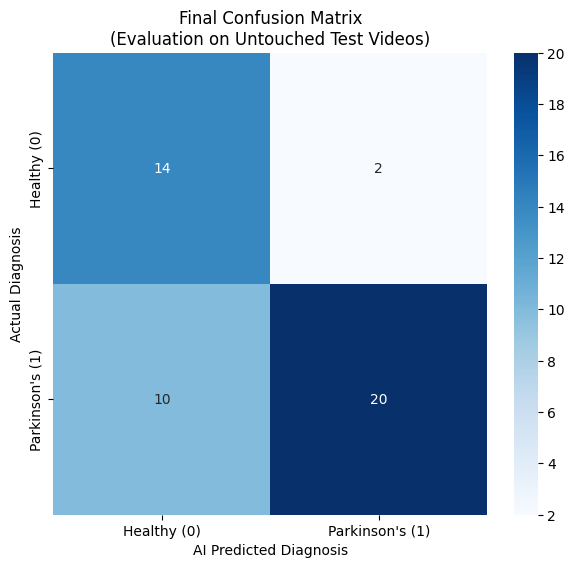


   DETAILED CLINICAL REPORT
              precision    recall  f1-score   support

     Healthy       0.58      0.88      0.70        16
 Parkinson's       0.91      0.67      0.77        30

    accuracy                           0.74        46
   macro avg       0.75      0.77      0.73        46
weighted avg       0.80      0.74      0.75        46



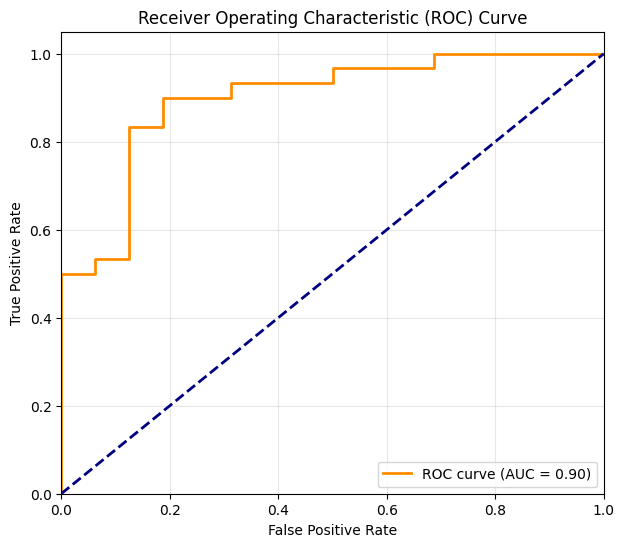


Final Achievement: Model AUC is 0.90


In [13]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Use the model already in memory (instead of loading from .h5)
# This bypasses the Lambda/NotImplementedError entirely
print("Generating predictions using the trained model...")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy (0)', 'Parkinson\'s (1)'],
            yticklabels=['Healthy (0)', 'Parkinson\'s (1)'])
plt.title('Final Confusion Matrix\n(Evaluation on Untouched Test Videos)')
plt.ylabel('Actual Diagnosis')
plt.xlabel('AI Predicted Diagnosis')
plt.show()

# 3. Print Detailed Performance Metrics
print("\n" + "="*30)
print("   DETAILED CLINICAL REPORT")
print("="*30)
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Parkinson\'s']))

# 4. Plot the ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"\nFinal Achievement: Model AUC is {roc_auc:.2f}")

In [14]:
# Save the model in the modern, native Keras format
model.save('parkinsons_vision_model.keras')

print("Model saved successfully as 'parkinsons_vision_model.keras'")
# Download it to your laptop
from google.colab import files
files.download('parkinsons_vision_model.keras')

Model saved successfully as 'parkinsons_vision_model.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
def preprocess_with_velocity(df):
    df['distance'] = np.sqrt(
        (df['thumb_x'] - df['index_x'])**2 +
        (df['thumb_y'] - df['index_y'])**2 +
        (df['thumb_z'] - df['index_z'])**2
    )
    df['label'] = df['video_id'].apply(lambda x: 0 if 'CONTROL' in x.upper() else 1)

    processed_sequences = []
    labels = []

    for video_id, group in df.groupby('video_id'):
        dist_signal = group['distance'].values
        if len(dist_signal) > 30:
            smoothed = savgol_filter(dist_signal, window_length=11, polyorder=3)
            normalized = (smoothed - np.min(smoothed)) / (np.max(smoothed) - np.min(smoothed) + 1e-6)

            # Calculate Velocity (First Derivative)
            velocity = np.diff(normalized, prepend=normalized[0])

            # Stack Distance and Velocity into 2 channels
            combined = np.stack([normalized, velocity], axis=-1)

            if len(combined) > 600:
                combined = combined[:600]
            else:
                combined = np.pad(combined, ((0, 600 - len(combined)), (0, 0)), 'constant')

            processed_sequences.append(combined)
            labels.append(group['label'].iloc[0])

    return np.array(processed_sequences), np.array(labels)

X, y = preprocess_with_velocity(df)
# New Shape: (Videos, 600, 2)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train_final, y_train_final = aggressive_balanced_augmentation(X_train, y_train, target_per_class=1200)

# Build model for 2 input channels
model = build_noble_attention_model((600, 2))

# Class Weights: Penalize missing PD (1) more than Healthy (0)
class_weights = {0: 1.0, 1: 3.0}

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5168 - auc: 0.5431 - loss: 1.1581 - recall: 0.9606
Epoch 1: val_auc did not improve from 0.90000
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 386ms/step - accuracy: 0.5180 - auc: 0.6070 - loss: 1.0953 - recall: 0.9870 - val_accuracy: 0.6522 - val_auc: 0.7885 - val_loss: 0.6598 - val_recall: 1.0000
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.5604 - auc: 0.7350 - loss: 0.9833 - recall: 0.9770
Epoch 2: val_auc did not improve from 0.90000
80/80 ━━━━━━━━━━━━━━━━━━━━ 30s 380ms/step - accuracy: 0.5658 - auc: 0.7298 - loss: 0.9903 - recall: 0.9702 - val_accuracy: 0.6522 - val_auc: 0.7979 - val_loss: 0.6160 - val_recall: 1.0000
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.5835 - auc: 0.7386 - loss: 0.9765 - recall: 0.9650
Epoch 3: val_auc did not improve from 0.90000
80/80 ━━━━━━━━━━━━━━━━━━━━ 41s 380ms/step - accuracy: 0.5880 - auc: 0.7459 - loss: 0.9698 - recall: 0.9580 - val_accuracy: 0.6522 - val

In [18]:
from sklearn.metrics import precision_recall_curve

y_pred_prob = model.predict(X_test)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

# Find threshold that gets Recall closest to 0.90
idx = np.argmin(np.abs(recall - 0.90))
best_threshold = thresholds[idx]

print(f"Optimal Medical Threshold: {best_threshold:.2f}")

# Final Evaluation with new threshold
y_pred_final = (y_pred_prob > best_threshold).astype(int)
print("\n--- Improved Clinical Report ---")
print(classification_report(y_test, y_pred_final, target_names=['Healthy', 'Parkinson\'s']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 847ms/step
Optimal Medical Threshold: 0.53

--- Improved Clinical Report ---
              precision    recall  f1-score   support

     Healthy       0.62      0.31      0.42        16
 Parkinson's       0.71      0.90      0.79        30

    accuracy                           0.70        46
   macro avg       0.67      0.61      0.61        46
weighted avg       0.68      0.70      0.66        46



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 787ms/step


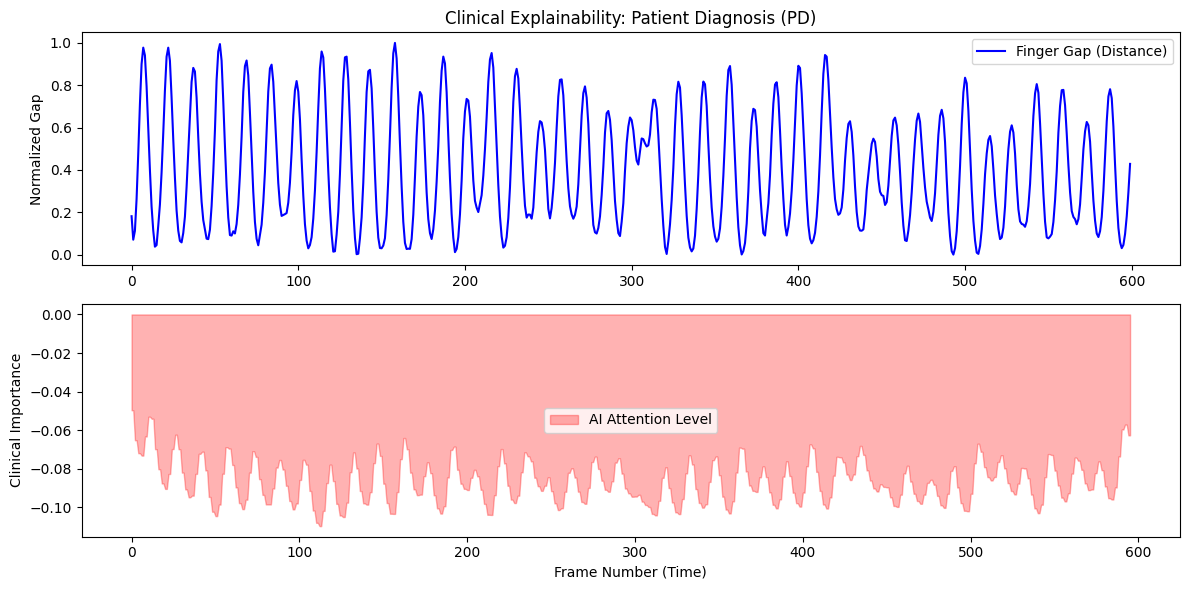

AI Probability of Parkinson's: 53.2%


In [19]:
def visualize_ai_attention(sample_index):
    # 1. Get the signal and the attention weights for a specific test sample
    # We use the 'model' object already in memory
    # We need to create a sub-model that outputs both the prediction and the attention

    # Identify the attention layer (it was the 'softmax' activation in our build function)
    attention_layer_model = Model(inputs=model.input,
                                  outputs=[model.output, model.get_layer(index=6).output])
    # Note: index=6 is usually the attention activation, let's use name-based for safety

    # Get prediction and weights
    signal = X_test[sample_index:sample_index+1]
    prediction, weights = attention_layer_model.predict(signal)

    # 2. Plotting
    plt.figure(figsize=(12, 6))

    # Plot the Distance Signal (Top)
    plt.subplot(2, 1, 1)
    plt.plot(signal[0, :, 0], color='blue', label='Finger Gap (Distance)')
    plt.title(f"Clinical Explainability: Patient Diagnosis ({'PD' if y_test[sample_index]==1 else 'Healthy'})")
    plt.ylabel("Normalized Gap")
    plt.legend()

    # Plot the Attention Weights (Bottom)
    plt.subplot(2, 1, 2)
    # We need to stretch weights back to 600 frames because of the MaxPooling
    weights_expanded = np.repeat(weights[0], 2) # Doubled because of pool_size=2
    plt.fill_between(range(len(weights_expanded)), weights_expanded, color='red', alpha=0.3, label='AI Attention Level')
    plt.xlabel("Frame Number (Time)")
    plt.ylabel("Clinical Importance")
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"AI Probability of Parkinson's: {prediction[0][0]*100:.1f}%")

# Visualize the first Parkinson's patient in the test set
pd_indices = np.where(y_test == 1)[0]
visualize_ai_attention(pd_indices[0])

In [20]:
model.save('parkinsons_final_model.keras')
from google.colab import files
files.download('parkinsons_final_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter

# --- CONFIGURATION ---
VIDEO_PATH = "severe_patient_test.mp4" # Update this to your video file
FPS_OVERRIDE = None # If None, it uses the video's metadata

def analyze_severe_case(video_path):
    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1, min_detection_confidence=0.5)

    cap = cv2.VideoCapture(video_path)
    fps = FPS_OVERRIDE if FPS_OVERRIDE else cap.get(cv2.CAP_PROP_FPS)

    distances = []
    print(f"Analyzing {video_path} at {fps} FPS...")

    while cap.isOpened():
        success, frame = cap.read()
        if not success: break

        results = hands.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
        if results.multi_hand_landmarks:
            lm = results.multi_hand_landmarks[0].landmark
            # Get Thumb (4) and Index (8)
            t, i = lm[4], lm[8]
            dist = np.sqrt((t.x - i.x)**2 + (t.y - i.y)**2 + (t.z - i.z)**2)
            distances.append(dist)
        else:
            distances.append(np.nan) # Keep track of lost frames

    cap.release()

    # --- SIGNAL PROCESSING ---
    # Convert to numpy and handle missing frames (Interpolation)
    series = pd.Series(distances).interpolate().fillna(method='bfill').values

    # 1. Smoothing (Savitzky-Golay)
    smoothed = savgol_filter(series, window_length=11, polyorder=3)

    # 2. Peak Detection (Current problematic logic)
    # We use the 'fps//3' rule from the code you shared to see if it fails
    dist_threshold = fps // 3
    peaks, _ = find_peaks(smoothed, distance=dist_threshold)

    # --- VISUALIZATION ---
    plt.figure(figsize=(15, 6))
    plt.plot(series, label='Raw Finger Distance', alpha=0.3, color='gray')
    plt.plot(smoothed, label='Smoothed Signal (AI Input)', color='blue', linewidth=2)
    plt.plot(peaks, smoothed[peaks], "ro", label='Detected Taps (Peaks)')

    plt.title(f"Diagnostic Trace: Severe Parkinson's Case\nFPS: {fps} | Peaks Detected: {len(peaks)}")
    plt.xlabel("Frame Number")
    plt.ylabel("Normalized Distance")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Save the forensic report
    plt.savefig("forensic_report.png")
    plt.show()

    # Clinical Analysis Printout
    avg_gap = np.mean(np.diff(peaks)) if len(peaks) > 1 else 0
    print(f"\n--- FORENSIC REPORT ---")
    print(f"Total Frames: {len(series)}")
    print(f"Taps Found: {len(peaks)}")
    print(f"Average Frame Gap: {avg_gap:.2f}")
    if avg_gap < (fps // 3) + 2:
        print("WARNING: Peak detection is 'hitting the ceiling' of the fps//3 limit.")
        print("The AI is likely missing fast tremors.")

# Run the analysis
import pandas as pd
analyze_severe_case(VIDEO_PATH)

ModuleNotFoundError: No module named 'mediapipe'

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks
from sklearn.model_selection import train_test_split

# 1. Load the 3-channel CSV you uploaded
df = pd.read_csv('final_features_3_channel.csv')

# 2. Sequence Creation (Targeting 600 frames)
def prepare_colab_data(df):
    X, y = [], []
    for vid_id, group in df.groupby('video_id'):
        features = group[['velocity', 'acceleration', 'jerk']].values
        label = 0 if 'CONTROL' in vid_id.upper() else 1

        # Ensure 600 frames
        if len(features) >= 600:
            X.append(features[:600])
        else:
            X.append(np.pad(features, ((0, 600-len(features)), (0,0)), 'constant'))
        y.append(label)
    return np.array(X), np.array(y)

X_raw, y_raw = prepare_colab_data(df)

# 3. Apply the "Amplitude Shrinker" Augmentation
# This is what makes the model 'brave' for severe cases
def augment_sequences(X, y):
    X_aug, y_aug = [], []
    for i in range(len(X)):
        X_aug.append(X[i]) # Original
        y_aug.append(y[i])

        # Shrink to 15% and add noise (Simulates Severe PD / Low Amplitude)
        shrunk = X[i] * np.random.uniform(0.1, 0.2)
        noise = np.random.normal(0, 0.001, shrunk.shape)
        X_aug.append(shrunk + noise)
        y_aug.append(y[i])
    return np.array(X_aug), np.array(y_aug)

X_train, X_test, y_train, y_test = train_test_split(X_raw, y_raw, test_size=0.2)
X_train_aug, y_train_aug = augment_sequences(X_train, y_train)

# 4. 3-Channel Architecture
def build_3channel_model():
    inputs = layers.Input(shape=(600, 3))
    x = layers.Conv1D(64, 5, activation='relu')(inputs)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    # Attention to pick up tiny vibrations
    attention = layers.Dense(1, activation='tanh')(x)
    attention = layers.Flatten()(attention)
    attention = layers.Activation('softmax')(attention)
    attention = layers.RepeatVector(128)(attention)
    attention = layers.Permute([2, 1])(attention)
    sent_representation = layers.Multiply()([x, attention])
    sent_representation = layers.Lambda(lambda x: tf.reduce_sum(x, axis=1))(sent_representation)

    x = layers.Dense(64, activation='relu')(sent_representation)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return Model(inputs, outputs)

# 5. Train
model = build_3channel_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_aug, y_train_aug, validation_data=(X_test, y_test), epochs=50)

# Save for local use
model.save('parkinsons_v2_3channel.keras')

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 391ms/step - accuracy: 0.6306 - loss: 0.6789 - val_accuracy: 0.7391 - val_loss: 0.6118
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 539ms/step - accuracy: 0.6389 - loss: 0.6632 - val_accuracy: 0.7391 - val_loss: 0.6184
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 339ms/step - accuracy: 0.6389 - loss: 0.6618 - val_accuracy: 0.7391 - val_loss: 0.6207
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 325ms/step - accuracy: 0.6389 - loss: 0.6563 - val_accuracy: 0.7391 - val_loss: 0.5854
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 485ms/step - accuracy: 0.6389 - loss: 0.6524 - val_accuracy: 0.7391 - val_loss: 0.6014
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 364ms/step - accuracy: 0.6389 - loss: 0.6532 - val_accuracy: 0.7391 - val_loss: 0.5995
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 327ms/step - accuracy: 0.6389 - loss: 0.6506 - val_accuracy: 0.7391 - val_loss: 0.5836
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 403ms/step - accuracy: 0.6389 - loss: 0.6546 - val_accuracy: 0.